## Remedial Jurnal Sementara M. Alfatih

In [160]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

Baris kode ini merupakan bagian untuk mengimpor library yang dibutuhkan. Library numpy diimpor dengan alias np dan digunakan untuk melakukan operasi matematis pada array multidimensi yang merepresentasikan piksel gambar. Library matplotlib.pyplot diimpor dengan alias plt dan digunakan untuk menampilkan gambar maupun grafik histogram secara visual. Library cv2 diimpor dengan alias cv dan digunakan khusus untuk membaca file gambar dari disk serta mengubahnya ke format grayscale.

In [195]:
citra1 = cv.imread('assets/citra1.png')
citra2 = cv.imread('assets/citra2.png')

Baris kode ini digunakan untuk membaca dua buah file gambar berformat PNG dari folder assets menggunakan fungsi cv.imread(). Gambar yang telah dibaca tersebut kemudian disimpan ke dalam variabel citra1 dan citra2. Hasil keluaran dari fungsi imread() ini berupa array multidimensi yang merepresentasikan matriks nilai piksel gambar, yang secara default dibaca dalam format warna BGR (Blue, Green, Red).

Baris kode ini digunakan untuk menampilkan kedua gambar yang telah dimuat sebelumnya secara berdampingan dalam satu kanvas menggunakan fungsi plt.subplot(1, 2, n) yang membagi kanvas menjadi grid 1 baris dan 2 kolom. Fungsi plt.imshow() digunakan untuk menampilkan gambar pada grid yang dipilih, plt.axis('off') untuk menyembunyikan sumbu koordinat agar tampilan visual lebih bersih, dan plt.title() untuk menambahkan teks judul pada masing-masing gambar.

(780, 780, 3)


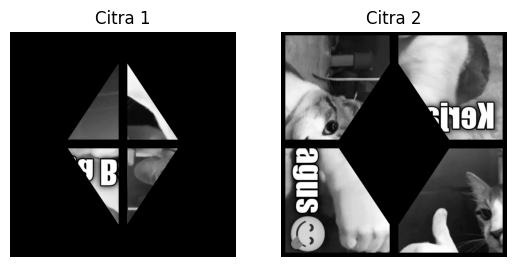

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(citra1)
plt.axis('off')
plt.title('Citra 1')

plt.subplot(1, 2, 2)
plt.imshow(citra2)
plt.axis('off')
plt.title('Citra 2')

In [163]:
gray1 = cv.cvtColor(citra1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(citra2, cv.COLOR_BGR2GRAY)

Baris kode diatas digunakan untuk mengonversi ruang warna dari kedua citra sebelumnya menjadi format skala abu-abu (grayscale) menggunakan fungsi cv.cvtColor(). Parameter cv.COLOR_BGR2GRAY s mengubah matriks gambar dari format BGR (Blue, Green, Red) yang memiliki tiga saluran warna menjadi format grayscale yang hanya memiliki satu saluran warna tunggal. Hasil dari proses konversi ini kemudian disimpan ke dalam variabel gray1 dan gray2.

Baris kode ini digunakan untuk menampilkan kedua citra berskala abu-abu (grayscale) yang telah dikonversi sebelumnya secara berdampingan. Fungsi plt.subplot(1, 2, n) membagi kanvas menjadi grid 1 baris dan 2 kolom. Fungsi plt.imshow() digunakan untuk merender matriks gambar dengan penambahan parameter cmap="gray" secara eksplisit guna memastikan visualisasi ditampilkan menggunakan peta warna abu-abu murni, karena secara bawaan (default) matplotlib menggunakan peta warna lain untuk array dua dimensi.dan plt.title() untuk menambahkan teks judul pada masing-masing citra.

Text(0.5, 1.0, 'Citra 2')

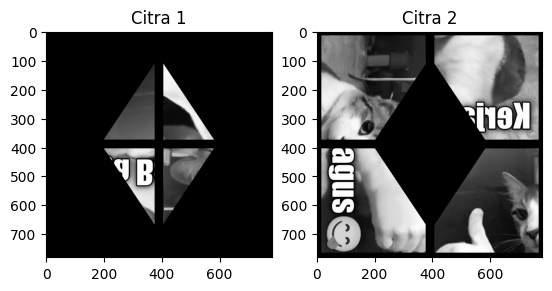

In [196]:
plt.subplot(1, 2, 1)
plt.imshow(gray1, cmap = "gray")
plt.title('Citra 1')

plt.subplot(1, 2, 2)
plt.imshow(gray2, cmap = "gray")
plt.title('Citra 2')

Baris kode ini mendefinisikan fungsi Rotasi() untuk memutar citra sebesar 90, 180, atau 270 derajat secara manual. Algoritma bekerja dengan menyiapkan matriks kosong berdimensi baru, lalu memetakan ulang koordinat setiap piksel dari citra asli ke posisi rotasinya menggunakan perulangan bertingkat (nested loop). Sudut masukan dinormalisasi dengan modulus 360, dan fungsi akan langsung mengembalikan citra asli tanpa perubahan jika perhitungan sudut bernilai 0.

In [165]:
def Rotasi(image, val):
    h, w = image.shape
    val = int(val) % 360
    if val == 0: return image
    elif val == 90:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[j, h - 1 - i] = image[i, j]
        return rot
    elif val == 180:
        rot = np.zeros((h, w), dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[h - 1 - i, w - 1 - j] = image[i, j]
        return rot
    elif val == 270:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[w - 1 - j, i] = image[i, j]
        return rot
    return image

Baris kode ini digunakan untuk memutar citra gray1 sebesar 180 derajat dengan memanggil fungsi Rotasi() yang telah didefinisikan sebelumnya, dan menyimpan hasilnya pada variabel rotasiawal. Matriks citra hasil rotasi tersebut kemudian ditampilkan  dalam format peta warna abu-abu (grayscale) menggunakan plt.imshow(), dilengkapi dengan judul "Setelah rotasi Citra 1" sebelum dirender oleh plt.show().

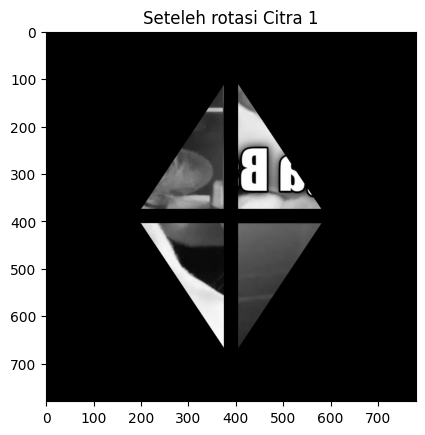

In [166]:
rotasiawal = Rotasi(gray1, 180)

plt.imshow(rotasiawal, cmap='gray')
plt.title("Seteleh rotasi Citra 1")
plt.show()

In [167]:
def Gabung(citra1, citra2):
    return citra1 + citra2

Baris kode ini mendefinisikan fungsi Gabung() yang digunakan untuk menjumlahkan dua buah citra digital menjadi satu kesatuan. Proses penggabungan dilakukan melalui operasi penjumlahan matriks s antara citra1 dan citra2 menggunakan operator aritmatika dasar.

Baris kode ini mengeksekusi penggabungan citra rotasiawal dan gray2 dengan memanggil fungsi Gabung(), lalu menyimpan hasilnya pada variabel mergeAwal. Matriks citra hasil gabungan tersebut kemudian divisualisasikan pada kanvas berukuran 6x5 inci menggunakan fungsi plt.imshow() dalam format warna grayscale. Tampilan ini disempurnakan dengan pemberian teks judul sebelum akhirnya dirender menggunakan plt.show().

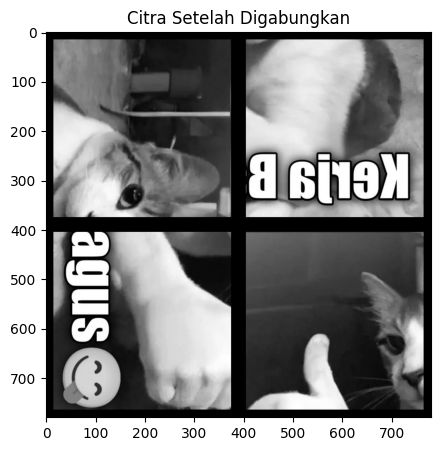

In [168]:
mergeAwal = Gabung(rotasiawal, gray2)

plt.figure(figsize=(6, 5))
plt.imshow(mergeAwal, cmap = 'gray')
plt.title('Citra Setelah Digabungkan')
plt.show()

In [169]:
def Slicing(gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

Baris kode ini membuat fungsi Slicing() untuk memotong bagian matriks citra berdasarkan batas indeks a hingga b. Jika mode='H', pemotongan dilakukan secara horizontal untuk mengambil baris tertentu menggunakan sintaks gambar[a:b, :]. Sebaliknya, pemotongan dilakukan secara vertikal pada kolom.

Baris kode dibawah ini menerapkan fungsi Slicing() untuk memotong citra mergeAwal menjadi empat kuadran (bagian). Pemotongan pertama membagi citra secara vertikal pada kolom indeks 390 menjadi bagian kiri dan kanan. Selanjutnya, bagian kiri dipotong horizontal menjadi kiriA dan kiriB, lalu bagian kanan juga dipotong horizontal menjadi kananA dan kananB.

In [170]:
potongKiri = Slicing(mergeAwal, 0, 390, 'V')
kiriA = Slicing(potongKiri, 0, 390, 'H')
kiriB = Slicing(potongKiri, 390, 800, 'H')
potongKanan = Slicing(mergeAwal, 390, 800, 'V')
kananA = Slicing(potongKanan, 0, 390, 'H')
kananB = Slicing(potongKanan, 390, 800, 'H')

Baris kode dibawah ini menampilkan keempat potongan citra (kiriA, kananA, kiriB, kananB) ke dalam satu kanvas menggunakan plt.subplot(2, 2, n) yang membentuk grid 2 baris dan 2 kolom. Setiap potongan divisualisasikan dalam format grayscale menggunakan plt.imshow(), dan diberi judul pada masing-masing bagiannya. Fungsi plt.tight_layout() ditambahkan agar jarak antar gambar terlihat rapi dan tidak tumpang tindih sebelum dirender dengan plt.show().

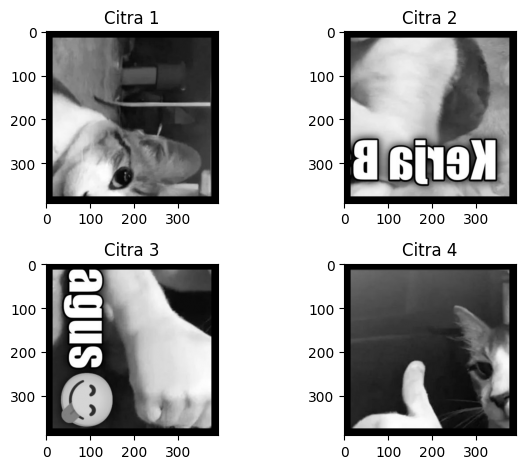

In [171]:
plt.subplot(2, 2, 1)
plt.imshow(kiriA, cmap = "gray")
plt.title('Citra 1')

plt.subplot(2, 2, 2)
plt.imshow(kananA, cmap = "gray")
plt.title('Citra 2')

plt.subplot(2, 2, 3)
plt.imshow(kiriB, cmap = "gray")
plt.title('Citra 3')

plt.subplot(2, 2, 4)
plt.imshow(kananB, cmap = "gray")
plt.title('Citra 4')
plt.tight_layout()
plt.show()

In [172]:
def Flipping(image, mode='X'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            if mode == 'X':
                hasil[i, j] = image[h - 1 - i, j]
            elif mode == 'Y':
                hasil[i, j] = image[i, w - 1 - j]
    return hasil

Baris kode ini mendefinisikan fungsi Flipping() untuk melakukan pencerminan citra secara manual menggunakan perulangan bertingkat. Algoritma bekerja dengan memetakan ulang setiap piksel dari citra asli ke matriks kosong yang baru dibuat. Jika mode='X', piksel dipetakan dengan membalikkan indeks baris untuk pencerminan vertikal, sedangkan mode='Y' membalikkan indeks kolom untuk pencerminan horizontal.

Baris kode dibawah ini mengeksekusi fungsi Flipping() untuk mencerminkan potongan citra kananA dan kananB secara horizontal (kiri ke kanan) dengan memberikan parameter mode='Y'. Hasil dari proses pencerminan matriks tersebut kemudian masing-masing disimpan ke dalam variabel baru, yaitu flippingCitra2 dan flippingCitra4.

In [173]:
flippingCitra2 = Flipping(kananA, 'Y')
flippingCitra4 = Flipping(kananB, 'Y')

Baris kode ini digunakan untuk menampilkan hasil pencerminan matriks pada flippingCitra2 dan flippingCitra4 secara berdampingan. Fungsi plt.subplot(1, 2, n) membagi kanvas menjadi grid 1 baris dan 2 kolom. Kedua citra divisualisasikan dalam format grayscale menggunakan plt.imshow(), lalu diberikan judul masing-masing menggunakan plt.title().

Text(0.5, 1.0, 'Citra 4')

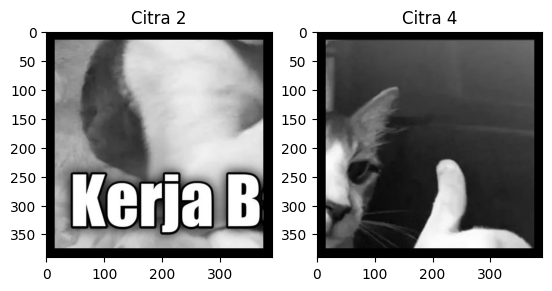

In [174]:
plt.subplot(1, 2, 1)
plt.imshow(flippingCitra2, cmap = "gray")
plt.title('Citra 2')

plt.subplot(1, 2, 2)
plt.imshow(flippingCitra4, cmap = "gray")
plt.title('Citra 4')

In [175]:
rotasiCitra1 = Rotasi(kiriA, 270)
rotasiCitra3 = Rotasi(kiriB, 270)

Baris kode ini memutar potongan citra kiriA dan kiriB sebesar 270 derajat dengan memanggil fungsi Rotasi() yang algoritmanya sudah dideklarasikan pada sel kode sebelumnya. Hasil dari perputaran matriks citra tersebut kemudian masing-masing disimpan ke dalam variabel rotasiCitra1 dan rotasiCitra3.

Baris kode dibawah ini digunakan untuk menampilkan hasil perputaran matriks pada rotasiCitra1 dan rotasiCitra3 secara berdampingan. Area kanvas dibagi menjadi 1 baris dan 2 kolom menggunakan fungsi plt.subplot(1, 2, n). Selanjutnya, kedua citra tersebut divisualisasikan dalam format grayscale menggunakan plt.imshow() dan diberikan teks judul.

Text(0.5, 1.0, 'Citra 3')

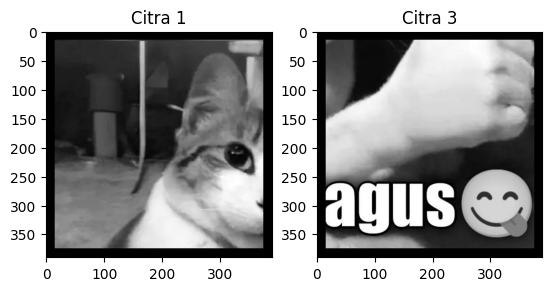

In [176]:
plt.subplot(1, 2, 1)
plt.imshow(rotasiCitra1, cmap = "gray")
plt.title('Citra 1')

plt.subplot(1, 2, 2)
plt.imshow(rotasiCitra3, cmap = "gray")
plt.title('Citra 3')

In [177]:
def Translasi(image, geser_kolom_x=0, geser_baris_y=0):
    image = np.array(image)
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            new_i = i + geser_baris_y
            new_j = j + geser_kolom_x
            if 0 <= new_i < h and 0 <= new_j < w:
                hasil[new_i, new_j] = image[i, j]
    return hasil

Baris kode ini mendefinisikan fungsi Translasi() untuk menggeser posisi citra secara horizontal sejauh x dan vertikal sejauh y. Algoritmanya bekerja dengan memindahkan setiap nilai piksel ke koordinat baru pada matriks kosong berdimensi sama menggunakan perulangan bertingkat. Pengecekan kondisi if disertakan untuk memastikan pemetaan piksel hanya dilakukan jika titik koordinat barunya tidak keluar dari batas ukuran matriks.

Baris kode ini menerapkan fungsi Translasi() untuk menggeser keempat potongan citra dengan arah yang berbeda-beda. trans1 dan trans3 digeser ke arah kanan (kolom +15), sedangkan trans2 dan trans4 digeser ke arah kiri (kolom -15). Secara vertikal, trans1 dan trans2 digeser ke bawah (baris +15), sementara trans3 dan trans4 digeser ke atas (baris -15).

In [178]:
trans1 = Translasi(rotasiCitra1, 15, 15)     
trans2 = Translasi(flippingCitra4, -15, 15)   
trans3 = Translasi(flippingCitra2, 15, -15)    
trans4 = Translasi(rotasiCitra3, -15, -15)  

Baris kode ini menampilkan keempat citra hasil translasi ke dalam grid 2x2 menggunakan kanvas berukuran 10x8 inci. Setiap citra dari variabel trans1 hingga trans4 ditampilkan pada posisi masing-masing menggunakan format grayscale. Pengaturan plt.subplot() menentukan tata letak gambar agar tersusun rapi dalam dua baris dan dua kolom. 

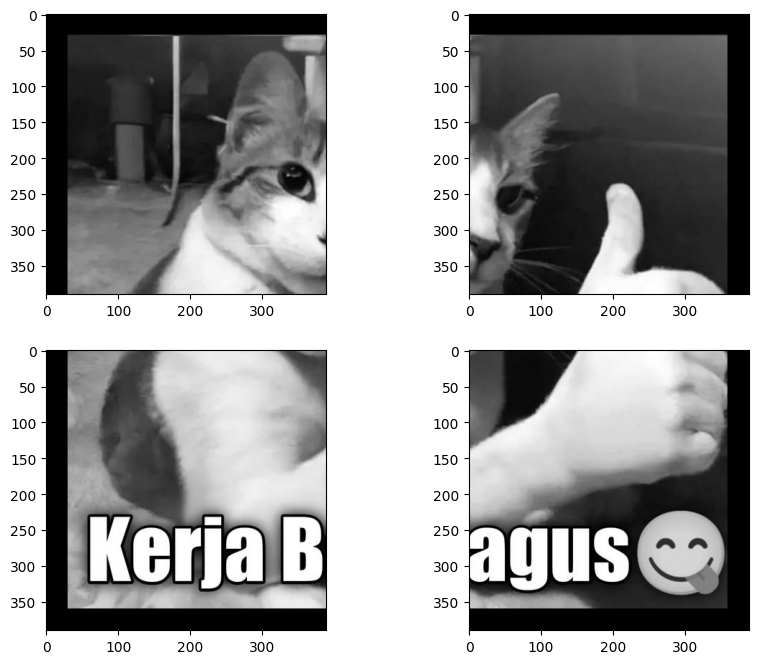

In [179]:
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1); plt.imshow(trans1, cmap='gray'); 
plt.subplot(2, 2, 2); plt.imshow(trans2, cmap='gray');
plt.subplot(2, 2, 3); plt.imshow(trans3, cmap='gray'); 
plt.subplot(2, 2, 4); plt.imshow(trans4, cmap='gray'); 

In [180]:
def Dilatasi(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape
    dilated = np.zeros((h*2, w*2), dtype=image.dtype)
    for y in range(h*2):
        for x in range(w*2):
            dilated[y][x] = image[int(y/2)][int(x/2)]
    sy, ey = max(0, p1), min(h*2, h*2-p2)
    sx, ex = max(0, p3), min(w*2, w*2-p4)
    return dilated[sy:ey, sx:ex]

Baris kode ini mendefinisikan fungsi Dilatasi() untuk memperbesar ukuran citra sebanyak dua kali lipat menggunakan teknik pemetaan piksel sederhana. Algoritma membuat matriks baru dengan dimensi dua kali lebih besar, lalu mengisi setiap koordinatnya dengan nilai piksel dari koordinat asal yang dibagi dua. Di akhir fungsi, terdapat fitur pemotongan (cropping) hasil perbesaran berdasarkan parameter p1 hingga p4 untuk menyesuaikan batas tepi citra.

Baris kode ini menjalankan fungsi Dilatasi() untuk memperbesar keempat citra hasil translasi sebelumnya menjadi dua kali lipat ukuran aslinya. Setiap variabel dilatasi menerima parameter pemotongan tepi yang berbeda. Hasil akhir dari proses perbesaran dan pemotongan koordinat ini kemudian disimpan ke dalam variabel dilatasi1 sampai dilatasi4.

In [181]:
dilatasi1 = Dilatasi(trans1, 60, 0, 60, 0)
dilatasi2 = Dilatasi(trans2, 60, 0, 0, 60)
dilatasi3 = Dilatasi(trans3, 0, 60, 60, 0)
dilatasi4 = Dilatasi(trans4, 0, 60, 0, 60)

Baris kode dibawah ini menampilkan keempat citra hasil perbesaran (dilatasi1 sampai dilatasi4) ke dalam satu kanvas berukuran 10x8 inci dengan tata letak grid 2x2. Setiap gambar divisualisasikan menggunakan format grayscale melalui fungsi plt.imshow() dan diberi judul "Citra 1" hingga "Citra 4" untuk memudahkan identifikasi.

Text(0.5, 1.0, 'Citra 4')

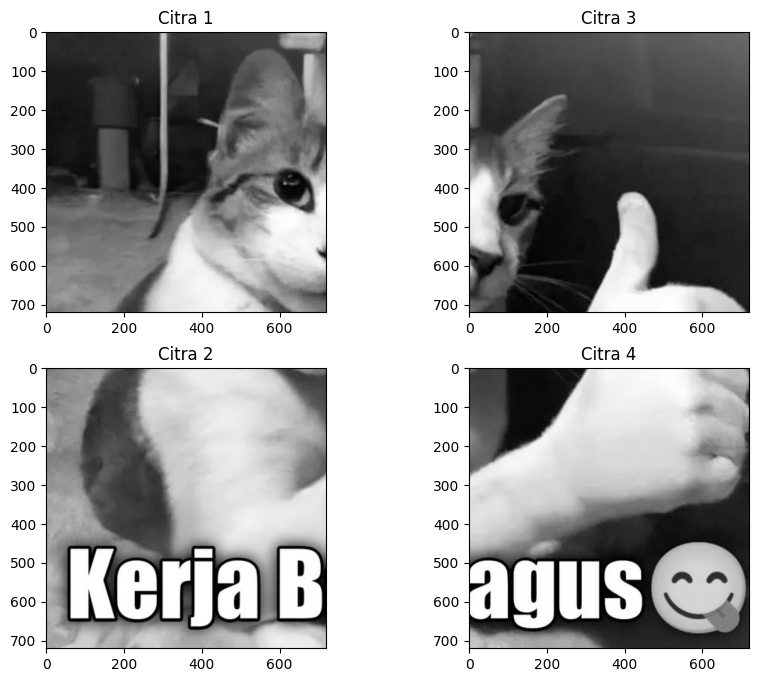

In [ ]:
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1); plt.imshow(dilatasi1, cmap='gray'); plt.title("Citra 1")
plt.subplot(2, 2, 2); plt.imshow(dilatasi2, cmap='gray'); plt.title("Citra 3")
plt.subplot(2, 2, 3); plt.imshow(dilatasi3, cmap='gray'); plt.title("Citra 2")
plt.subplot(2, 2, 4); plt.imshow(dilatasi4, cmap='gray'); plt.title("Citra 4")

In [183]:
def merge_horizontal(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:] = c2 
    return hasil 

def merge_vertikal(citra_1, citra_2): 
    c1, c2 = np.array(citra_1), np.array(citra_2) 
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2 
    return hasil 

Baris kode ini mendefinsikan merge_horizontal yang menggabungkan dua citra secara berdampingan (kiri-kanan) dengan menjumlahkan lebar keduanya dan menempatkannya pada matriks nol yang baru. Sedangkan merge_vertikal menggabungkan dua citra secara bertumpuk (atas-bawah) dengan menjumlahkan tinggi keduanya dan menyusunnya secara berurutan dalam satu matriks.

Baris kode dibawah ini menggabungkan potongan citra secara horizontal untuk membentuk baris-baris penyusun citra yang baru. Variabel merge13 menampung hasil penggabungan dilatasi1 dan dilatasi2 (sisi kiri dan kanan bagian atas), sedangkan merge24 menggabungkan dilatasi3 dan dilatasi4 (sisi kiri dan kanan bagian bawah).

In [184]:
merge13 = merge_horizontal(dilatasi1, dilatasi2)
merge24 = merge_horizontal(dilatasi3, dilatasi4)  

Baris kode dibawah ini melakukan penggabungan akhir dengan menyatukan baris merge13 (bagian atas) dan merge24 (bagian bawah) secara vertikal menggunakan fungsi merge_vertikal(). Hasilnya disimpan dalam variabel merge1234 yang merupakan citra utuh kembali, lalu divisualisasikan menggunakan plt.imshow() dalam format grayscale.

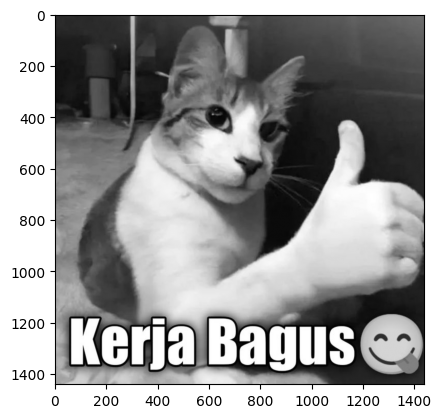

In [185]:
merge1234 = merge_vertikal(merge13, merge24)
plt.imshow(merge1234, cmap='gray')

In [186]:
def normalisasi(citra):
    min_val = int(citra[0,0])
    max_val = int(citra[0,0])
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            if citra[i,j] < min_val: min_val = int(citra[i,j])
            if citra[i,j] > max_val: max_val = int(citra[i,j])
    
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hasil[i,j] = int((int(citra[i,j]) - min_val) / (max_val - min_val) * 255)
    return hasil

def hitung_histogram(citra):
    hist = np.zeros(256, dtype=int)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hist[citra[i, j]] += 1
    return hist

Baris kode ini mendefinisikan dua fungsi untuk pengolahan kontras dan analisis distribusi warna citra.
normalisasi adalah fungsi yang melakukan peregangan kontras (contrast stretching) secara manual. Algoritmanya mencari nilai piksel terendah (min_val) dan tertinggi (max_val), lalu memetakan ulang setiap piksel ke rentang 0-255 agar distribusi warna lebih merata.
Sedangkan fungsi hitung_histogram berguna untuk menghitung frekuensi kemunculan setiap nilai intensitas piksel (0-255). Hasilnya berupa array 1D yang merepresentasikan distribusi kecerahan citra tersebut.

Baris kode ini digunakan untuk memproses normalisasi citra dan membandingkan distribusi intensitas pikselnya melalui histogram
Variabel citrasebelum dibuat dengan membagi nilai piksel merge1234 menjadi setengahnya (reduksi kecerahan), lalu diubah kembali ke tipe data uint8.
Fungsi normalisasi() dipanggil untuk merentangkan kembali kontras citra yang redup tersebut ke jangkauan penuh (0-255).
Fungsi hitung_histogram() mengukur frekuensi kemunculan tiap nilai intensitas pada citra sebelum dan sesudah diproses.
Visualisasi menggunakan plt.bar(), distribusi piksel ditampilkan berdampingan. Histogram biru menunjukkan intensitas yang menumpuk di area gelap (karena pembagian 2), sedangkan histogram hijau menunjukkan distribusi yang lebih luas dan merata setelah dinormalisasi.

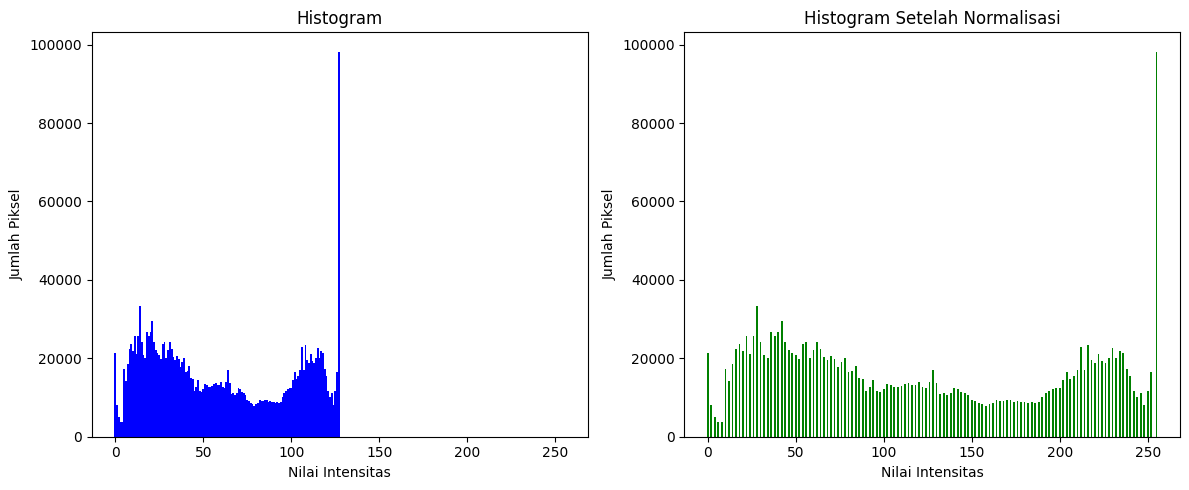

In [187]:

citrasebelum= (merge1234 / 2).astype(np.uint8)
norm = normalisasi(citrasebelum)

hist_sebelum = hitung_histogram(citrasebelum)
hist_sesudah = hitung_histogram(norm)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(256), hist_sebelum, width=1, color='blue')
plt.title('Histogram')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')

plt.subplot(1, 2, 2)
plt.bar(range(256), hist_sesudah, width=1, color='green')
plt.title('Histogram Setelah Normalisasi')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

In [188]:
kernel = [
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
]

def zero_padding(citra, pad):
    h, w = citra.shape
    hasil = np.zeros((h + 2*pad, w + 2*pad), dtype=citra.dtype)
    hasil[pad:pad+h, pad:pad+w] = citra
    return hasil

def konvolusi(citra, kernel):
    k_h = len(kernel)
    k_w = len(kernel[0])
    pad = k_h // 2
    
    citra_pad = zero_padding(citra, pad)
    h, w = citra.shape
    hasil = np.zeros((h, w), dtype=np.float64)
    
    for i in range(h):
        for j in range(w):
            total = 0.0
            for ki in range(k_h):
                for kj in range(k_w):
                    total += citra_pad[i+ki, j+kj] * kernel[ki][kj]
            hasil[i, j] = total
    
    return hasil

def clipping(citra):
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            val = citra[i, j]
            hasil[i, j] = 255 if val > 255 else (0 if val < 0 else int(val))
    return hasil

Baris kode diatas mendefinisikan beberapa hal diantaranya
Kernel adalah matriks yang bakal digeser ke seluruh bagian gambar untuk mengubah efeknya.
Zero Padding berfungsi biar pinggiran gambar tidak hilang atau mengecil setelah difilter, gambar aslinya dikasih bingkai tambahan berisi angka nol.
Konvolusi yaitu proses mengalikan nilai piksel asli dengan angka di matriks, lalu menjumlahkannya jadi nilai piksel baru.
Clipping dipakai karena hasil hitung-hitungan tadi bisa jadi berantakan (misalnya hasilnya minus atau lebih dari 255), fungsi ini bertugas "memaksa" nilainya balik ke aturan warna normal, yaitu di antara 0 sampai 255.

Baris kode dibawah ini menjalankan proses pemfilteran akhir dengan menerapkan konvolusi menggunakan kernel pada citra yang telah dinormalisasi. Hasilnya kemudian diproses melalui fungsi clipping agar nilai pikselnya tetap berada di rentang standar 0 hingga 255. Terakhir, citra tersebut ditampilkan dalam format grayscale untuk melihat hasil penajaman atau efek detail yang dihasilkan oleh filter tersebut.

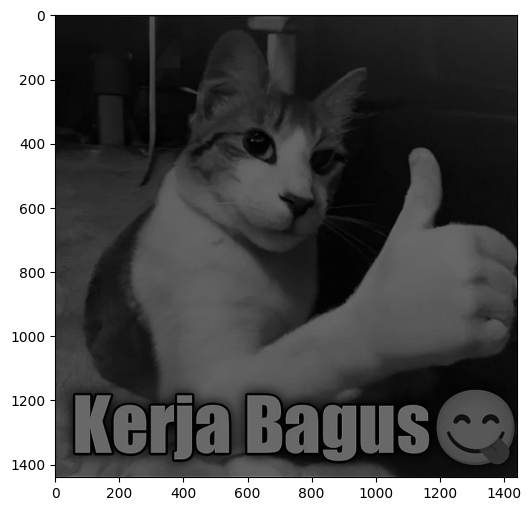

In [189]:
citra_conv = konvolusi(norm, kernel)
citra_clip = clipping(citra_conv)

plt.figure(figsize=(6, 6))
plt.imshow(citra_clip, cmap='gray')
plt.show()

Baris kode dibawah ini digunakan untuk menghitung dan menampilkan distribusi warna terakhir setelah citra diberikan efek filter konvolusi.Penggunaan fungsi hitung_histogram untuk melihat sebaran nilai intensitas piksel pada variabel citra_clip yang sudah melalui proses clipping. Hasilnya divisualisasikan dalam bentuk grafik batang berwarna hijau

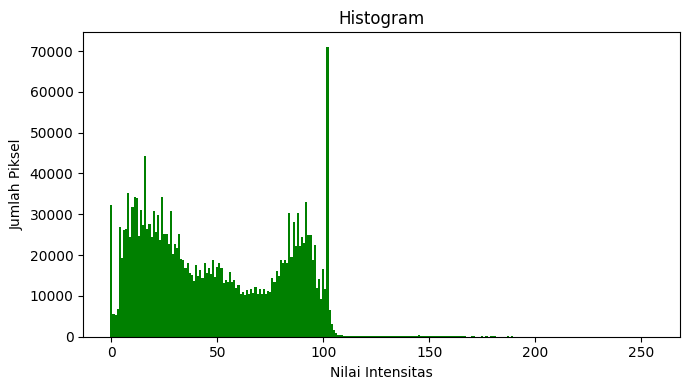

In [190]:
hist_akhir = hitung_histogram(citra_clip)
plt.figure(figsize=(7, 4))
plt.bar(range(256), hist_akhir, width=1, color='green')
plt.title('Histogram')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Piksel')
plt.tight_layout()
plt.show()

Analisa Hasil Akhir: Jurnal Modul 1 ini memproses empat potongan citra melalui serangkaian transformasi geometri dan perbaikan kualitas yang saling terintegrasi. Setiap fragmen citra mengalami rotasi, pencerminan, translasi, hingga pembesaran dua kali lipat melalui dilatasi dengan penyesuaian tepi agar objek tetap presisi saat disatukan kembali menjadi citra utuh. Kualitas visual kemudian ditingkatkan melalui normalisasi untuk memperluas rentang intensitas piksel, serta penerapan konvolusi dengan teknik zero padding dan clipping untuk mempertajam detail objek tanpa merusak batas nilai warna valid.